In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
df = pd.read_csv('Datasets/BostonHousing.csv')

In [7]:
print(df.head())

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [8]:
print("Rows and Columns:", df.shape)

Rows and Columns: (506, 14)


In [9]:
print(df.isnull().sum())

crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


In [10]:
df = df.fillna(df.mean())


In [14]:
# Separate Input(X) and Output(y)
X = df.drop("medv", axis=1)
y = df["medv"]

In [16]:
print(df.columns)

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='str')


In [17]:
# Split Data into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [18]:
# Create Linear Regression Model
model = LinearRegression()


In [19]:
# Train Model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
# Predict Test Data
y_pred = model.predict(X_test)

In [21]:
# Print Actual and Predicted Values
result = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})
print(result.head(10))

     Actual Price  Predicted Price
173          23.6        28.981419
274          32.4        36.014232
491          13.6        14.824309
72           22.8        25.022936
452          16.1        18.770774
76           20.0        23.250889
316          17.8        17.659214
140          14.0        14.331216
471          19.6        23.017996
500          16.8        20.619237


In [22]:
# Check Accuracy using R2 Score
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.6672089705941886


In [23]:
# Check Error using Mean Squared Error
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

Mean Squared Error: 24.404825188146436


In [24]:
import matplotlib.pyplot as plt

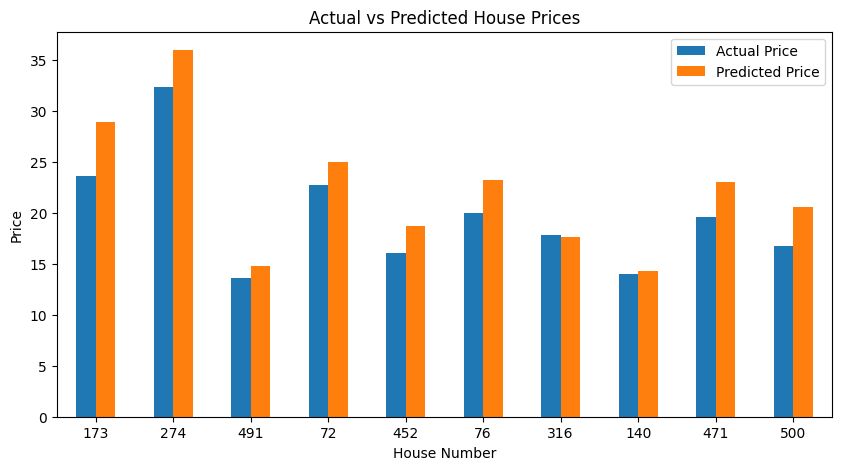

In [27]:
result.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Actual vs Predicted House Prices")
plt.xlabel("House Number")
plt.ylabel("Price")
plt.xticks(rotation=0)
plt.show()